Sai Kadiravan S

NLP Assignment-2

###1. Data Understanding

In [1]:
!pip install pandas numpy scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('IMDB Dataset.csv')

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


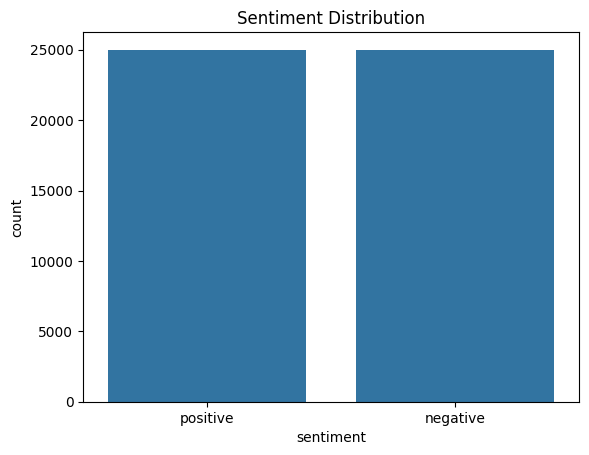

In [11]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [14]:
print("Sample Positive Review:\n")
print(df[df['sentiment']=='positive']['review'].iloc[0])

print("\n" + "="*80 + "\n")

print("Sample Negative Review:\n")
print(df[df['sentiment']=='negative']['review'].iloc[0])

Sample Positive Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of t

###2. NLP Preprocessing

In [15]:
!pip install nltk

In [16]:
import nltk
import re

In [22]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [20]:
def preprocess_text(text):

    # 1. Lowercasing
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 4. Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 8. Join words back
    text = ' '.join(tokens)

    return text

In [23]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [24]:
print("Original Review:\n", df['review'][0])
print("\nCleaned Review:\n", df['cleaned_review'][0])

Original Review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [25]:
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


###3. Feature Engineering

In [26]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [28]:
print(X_train_bow.shape)
print(X_test_bow.shape)

(40000, 5000)
(10000, 5000)


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [30]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(40000, 5000)
(10000, 5000)


###4. Model Building

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [34]:
# Logistic regression using tfidf
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [35]:
# Naive Bayes using tfidf
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [36]:
# Decision tree usingtfidf
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train_tfidf, y_train)

y_pred_dt = dt_model.predict(X_test_tfidf)

In [37]:
# Logistic regression using BoW
lr_bow = LogisticRegression(max_iter=200)
lr_bow.fit(X_train_bow, y_train)

y_pred_lr_bow = lr_bow.predict(X_test_bow)

In [38]:
# Naive Bayes (BoW)
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

y_pred_nb_bow = nb_bow.predict(X_test_bow)

In [39]:
# Decision Tree (BoW)
dt_bow = DecisionTreeClassifier()
dt_bow.fit(X_train_bow, y_train)

y_pred_dt_bow = dt_bow.predict(X_test_bow)

###5. Model Evaluation

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [45]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\n")

    return acc, prec, rec, f1

In [47]:
results = {}

results['LR_TFIDF'] = evaluate_model(y_test, y_pred_lr, "Logistic Regression (TF-IDF)")
results['NB_TFIDF'] = evaluate_model(y_test, y_pred_nb, "Naive Bayes (TF-IDF)")
results['DT_TFIDF'] = evaluate_model(y_test, y_pred_dt, "Decision Tree (TF-IDF)")

--- Logistic Regression (TF-IDF) ---
Accuracy : 0.8888
Precision: 0.8791
Recall   : 0.9036
F1 Score : 0.8912


--- Naive Bayes (TF-IDF) ---
Accuracy : 0.8546
Precision: 0.8514
Recall   : 0.8619
F1 Score : 0.8566


--- Decision Tree (TF-IDF) ---
Accuracy : 0.7140
Precision: 0.7179
Recall   : 0.7122
F1 Score : 0.7151




In [48]:
results['LR_BOW'] = evaluate_model(y_test, y_pred_lr_bow, "Logistic Regression (BoW)")
results['NB_BOW'] = evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (BoW)")
results['DT_BOW'] = evaluate_model(y_test, y_pred_dt_bow, "Decision Tree (BoW)")

--- Logistic Regression (BoW) ---
Accuracy : 0.8729
Precision: 0.8685
Recall   : 0.8811
F1 Score : 0.8748


--- Naive Bayes (BoW) ---
Accuracy : 0.8516
Precision: 0.8564
Recall   : 0.8476
F1 Score : 0.8520


--- Decision Tree (BoW) ---
Accuracy : 0.7162
Precision: 0.7181
Recall   : 0.7190
F1 Score : 0.7186




In [49]:
results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

results_df

,Accuracy,Precision,Recall,F1 Score
LR_TFIDF,0.8888,0.879127,0.903552,0.891172
NB_TFIDF,0.8546,0.851402,0.861877,0.856607
DT_TFIDF,0.7140,0.717944,0.712244,0.715083
LR_BOW,0.8729,0.868545,0.881127,0.874791
NB_BOW,0.8516,0.856427,0.847589,0.851985
DT_BOW,0.7162,0.718137,0.718992,0.718564


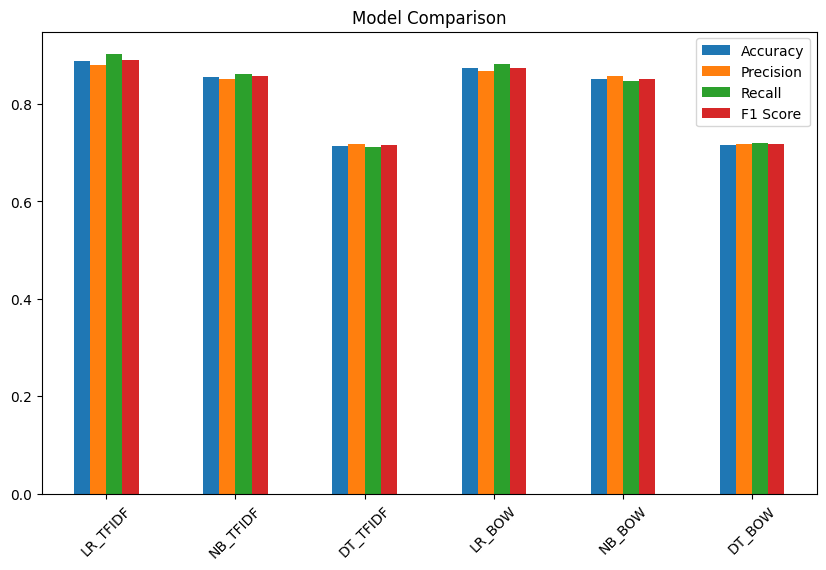

In [51]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

###6. Comparison & Insights

In [52]:
best_model = results_df['F1 Score'].idxmax()
best_score = results_df['F1 Score'].max()

print("Best Model:", best_model)
print("Best F1 Score:", best_score)

Best Model: LR_TFIDF
Best F1 Score: 0.8911724407907614


In [53]:
results_df.sort_values(by='F1 Score', ascending=False)

,Accuracy,Precision,Recall,F1 Score
LR_TFIDF,0.8888,0.879127,0.903552,0.891172
LR_BOW,0.8729,0.868545,0.881127,0.874791
NB_TFIDF,0.8546,0.851402,0.861877,0.856607
NB_BOW,0.8516,0.856427,0.847589,0.851985
DT_BOW,0.7162,0.718137,0.718992,0.718564
DT_TFIDF,0.7140,0.717944,0.712244,0.715083


###Insights

1. Preprocessing

The preprocessing step played a very important role in improving the model performance. Converting text to lowercase, removing HTML tags, special characters, and stopwords helped reduce noise in the data. Lemmatization was especially useful as it converted words to their base form without losing meaning. Overall, cleaning the text made the data more consistent and easier for the models to learn from.

2. Vectorization

Between Bag of Words and TF-IDF, TF-IDF performed better. Bag of Words simply counts word frequency, but TF-IDF gives importance to words that are more meaningful in a particular review and less importance to very common words. This helped improve the model’s ability to distinguish between positive and negative sentiments.

3. Best Model

Logistic Regression gave the best results among all the models. It worked well with high-dimensional text data and produced strong performance across accuracy, precision, recall, and F1-score. Naive Bayes also performed well but was slightly less accurate. Decision Tree had the lowest performance, likely due to overfitting and difficulty handling sparse text features.

4. Trade-offs

Each model has its own advantages and disadvantages. Logistic Regression provides high accuracy but takes slightly more time to train. Naive Bayes is very fast and efficient but may not always give the best accuracy. Decision Tree is easy to understand and interpret, but it does not perform well on text data and can overfit easily.

Overall, TF-IDF combined with Logistic Regression gave the best performance for this sentiment analysis task.